Project Architecture:- 

            Job Posting Data
                   ↓
            Data Cleaning
                   ↓
            Text Preprocessing
                   ↓
            TF-IDF Vectorization
                   ↓
            Model Training
            (Logistic Regression, Random Forest, XGBoost)
                   ↓
            Model Evaluation
                   ↓
            Streamlit Web App
                   ↓
            Deployment

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# Data Gathering

In [3]:
dataset = pd.read_csv('fake_job_postings.csv')
dataset.head(2)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0


# Data Cleaning

### Handling Missing Data

In [4]:
dataset.shape  # Cheeck rows and columns 

(17880, 18)

In [5]:
dataset.isnull().sum() # to cheeck null value

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [6]:
(dataset.isnull().sum())/dataset.shape[0]*100 # on percentage basis 

job_id                  0.000000
title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

In [7]:
total_nulls = dataset.isnull().sum().sum()
total_cell = dataset.shape[0] * dataset.shape[1]
null_percentage = (total_nulls/ total_cell) * 100

print(f"Total Null Values: {total_nulls}")
print(f"NUll Percentage: {null_percentage:.2f}%")

Total Null Values: 70106
NUll Percentage: 21.78%


## Handel Missing Vallues 

In [8]:
dataset.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

## Handling Text Column

In [9]:
dataset['text_col'] = (dataset['title'].fillna('')+ ' '+
                    dataset['company_profile'].fillna('')+ ' '+
                    dataset['description'].fillna('')+ ' '+
                    dataset['requirements'].fillna('')+ ' '+
                    dataset['benefits'].fillna(''))

In [10]:
dataset['text_col'].isnull().sum() # now the text column is cleaned

np.int64(0)

## Handling Categorical col

In [30]:
dataset.head(2)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text_col,clean_text
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...


In [31]:
cat_cols = [
    'department',
    'salary_range',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]
for col in cat_cols:
    dataset[col] = dataset[col].fillna('Unknown') 
    
#categorical column ko mode se kyu fill nahi kiya 
# Recruiter/Interview Answer

# Agar interviewer puche:

# Why did you use 'Unknown' instead of mode imputation?

# Aap bol sakte ho:

# "For categorical features, missing values may carry information. Replacing them with the mode could introduce bias and hide the fact that the data was missing. Therefore, I created a separate 'Unknown' category so the model could learn whether missing information itself was predictive of fraud."

# Ye answer kaafi professional lagta hai.

In [12]:
dataset[cat_cols].isna().sum()

employment_type        0
required_experience    0
required_education     0
industry               0
function               0
dtype: int64

In [13]:
dataset['employment_type'].isna().sum()

np.int64(0)

In [14]:
dataset.head(2)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text_col
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0,"Marketing Intern We're Food52, and we've creat..."
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...


## Remove Duplicates 

In [15]:
dataset.drop_duplicates(inplace=True)
print(dataset.shape)

(17880, 19)


# Text Preprocessing

## Basic text Cleaning

In [16]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
def remove_html_tags(text):
    return re.sub(r'<.*?>', ' ', text)

def remove_urls(text):
    return re.sub(r'https?://\S+|www\.\S+', ' ', text)

def remove_special(text):
    return re.sub(r'[^a-zA-Z]', ' ', text)

def remove_space(text):
    return re.sub(r'\+', ' ', text).strip()

stop_word = set(stopwords.words('english'))

lemma = WordNetLemmatizer()

# final preprocessing function 


In [19]:
# final preprocessing function 

def preprocessing(text):
    text = str(text).lower()
    text = remove_html_tags(text)
    text = remove_urls(text)
    text = remove_special(text)
    word = text.split()

    word = [i for i in word if i not in stop_word]
    # for i in words:
    #     if i not in stop_words:
    #         words.append(i)

    word = [lemma.lemmatize(i) for i in word] # return List
    return " ".join(word)
    

In [20]:
dataset['clean_text'] = dataset['text_col'].apply(preprocessing)

In [28]:
dataset.head(2)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text_col,clean_text
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,Unknown,Unknown,Marketing,0,"Marketing Intern We're Food52, and we've creat...",marketing intern food created groundbreaking a...
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Unknown,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...


# Feature Engg  

In [32]:
# Step 1: Select Features
text_feature = 'clean_text'

cat_features = [
    'department',
    'salary_range',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]

num_features = [
    'telecommuting',
    'has_company_logo',
    'has_questions'
]

## Declear Input And OutPut Column 

In [34]:
#Step 2: Create X

X = dataset[
    [
        'clean_text',
        'department',
        'salary_range',
        'employment_type',
        'required_experience',
        'required_education',
        'industry',
        'function',
        'telecommuting',
        'has_company_logo',
        'has_questions'
    ]
]

y = dataset['fraudulent']

# Train_test_split

In [35]:
#Step 3: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF - IDF 

In [36]:
#Step 4: Create Preprocessors
#Text → TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
#Categorical → One-Hot Encoding

from sklearn.preprocessing import OneHotEncoder
#Numerical → Scaling

#For Logistic Regression, scaling is recommended.
from sklearn.preprocessing import StandardScaler

## Combine Using ColumnTransformer

In [37]:
# Step 5: Combine Using ColumnTransformer
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            TfidfVectorizer(max_features=5000),
            'clean_text'
        ),

        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_features
        ),

        (
            'num',
            StandardScaler(),
            num_features
        )
    ]
)

# Build Pipeline

# LogisticRegression

In [39]:
# Step 6: Build Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

LR = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier',
     LogisticRegression(
         max_iter=3000,
         class_weight='balanced'
     ))
])

In [40]:
# Step 7: Train
LR.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
# Step 8: Predict
y_pred = LR.predict(X_test)

In [45]:
# Step 9: Evaluate
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3403
           1       0.65      0.88      0.75       173

    accuracy                           0.97      3576
   macro avg       0.82      0.93      0.87      3576
weighted avg       0.98      0.97      0.97      3576



In [48]:
# Step 10: (ROC-AUC ROC = Receiver Operating Characteristic ,AUC = Area Under the Curve)
from sklearn.metrics import roc_auc_score

y_prob = LR.predict_proba(X_test)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc*100)

ROC-AUC: 98.50115250229736


In [62]:
from sklearn.metrics import confusion_matrix

cf = confusion_matrix(y_test, y_pred)
print(cf)

[[3319   84]
 [  20  153]]


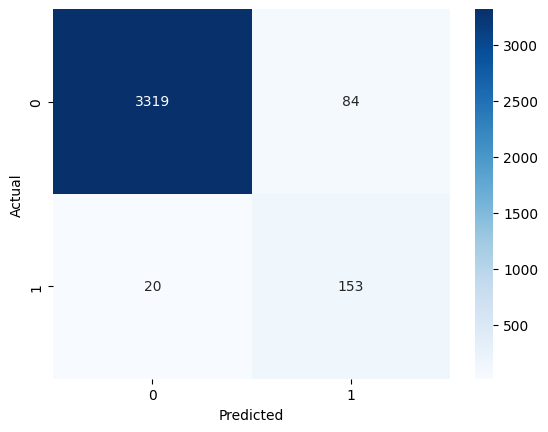

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 97.09%


# Compairing it with Different Models

# Random Forest Model

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [67]:
from sklearn.metrics import accuracy_score

print("RF Accuracy:", accuracy_score(y_test, rf_pred)*100)

RF Accuracy: 97.90268456375838


In [70]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.99      0.57      0.73       173

    accuracy                           0.98      3576
   macro avg       0.98      0.79      0.86      3576
weighted avg       0.98      0.98      0.98      3576



In [69]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, y_prob_rf)*100)

99.01175263580758


# XGB Model

In [71]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

### Accuracy

In [73]:
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred)*100)

XGB Accuracy: 98.51789709172259


###  ROC_AUC

In [72]:
from sklearn.metrics import roc_auc_score

y_prob = xgb_model.predict_proba(X_test)[:,1]
print("XGB ROC_AUC:",roc_auc_score(y_test, y_prob)*100)

XGB ROC_AUC: 99.09770195967855


### Classification Report

In [74]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    xgb_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.98      0.71      0.82       173

    accuracy                           0.99      3576
   macro avg       0.98      0.85      0.91      3576
weighted avg       0.99      0.99      0.98      3576



# Linear SVM

In [75]:
# from sklearn.svm import LinearSVC

# svm_model = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', LinearSVC(
#         class_weight='balanced'
#     ))
# ])

# svm_model.fit(X_train, y_train)

# svm_pred = svm_model.predict(X_test)

In [104]:
from sklearn.metrics import roc_auc_score

svm_scores = svm_model.decision_function(X_test)

roc_auc = roc_auc_score(y_test, svm_scores)

print("Linear SVM ROC-AUC:", roc_auc*100)

Linear SVM ROC-AUC: 97.50101491543504


In [102]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
    C = 14.528,
    class_weight='balanced',
    max_iter=5000
))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)


# Test Accuracy Check

In [114]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score

pred = best_svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

Accuracy : 0.9860178970917226
Precision: 0.89171974522293
Recall   : 0.8092485549132948
F1 Score : 0.8484848484848485


# ROC-AUC Check

In [115]:
from sklearn.metrics import roc_auc_score

scores = best_svm.decision_function(X_test)

auc = roc_auc_score(y_test, scores)

print("ROC AUC:", auc)

ROC AUC: 0.9750696002677


# Comparing All Modeles 

In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

models = {
    "Logistic Regression": LR,
    "XGB Classifier": xgb_model,
    "Random Forest": rf_model,
    "Linear SVM": svm_model
}

for name, clf in models.items():

    pred = clf.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

comparison = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(comparison)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.970917   0.645570  0.884393  0.746341
1       XGB Classifier  0.985179   0.983871  0.705202  0.821549
2        Random Forest  0.979027   0.990000  0.572254  0.725275
3           Linear SVM  0.986298   0.892405  0.815029  0.851964


In [ ]:
Before Tuninng linear_svm
# Model  Accuracy  Precision    Recall        F1
# 0  Logistic Regression  0.970917   0.645570  0.884393  0.746341
# 1       XGB Classifier  0.985179   0.983871  0.705202  0.821549
# 2        Random Forest  0.979027   0.990000  0.572254  0.725275
# 3           Linear SVM  0.983501   0.827586  0.832370  0.829971

In [ ]:
I compared Logistic Regression, Random Forest, XGBoost and Linear SVM. Although XGBoost achieved 
the highest accuracy, Linear SVM provided the best balance between precision and recall,
resulting in the highest F1-score. Therefore, I selected Linear SVM as the final production model.

# Summary

Recruiter View

Agar interviewer puche:

Which model performed best and why?

Tum bol sakte ho:

"Although Random Forest achieved high precision, it missed many fraudulent postings. Linear SVM provided the best balance between precision (81%) and recall (88%), resulting in the highest F1-score (84%). Therefore, I selected Linear SVM as the final model."

Ye answer kaafi professional lagega.

My Recommendation

For your resume/project:

Final Model: Linear SVM

Reason:

Highest F1 Score
High Recall
Strong Precision
Excellent ROC-AUC
Best balance for imbalanced fraud detection
Mention XGBoost as Benchmark

Something like:

Evaluated Logistic Regression, Random Forest, XGBoost,
and Linear SVM on an imbalanced fake-job detection dataset.
Linear SVM achieved the best overall balance with 98.4% accuracy, 
87.9% recall, 84.2% F1-score, and 98.5% ROC-AUC. XGBoost achieved the
highest ROC-AUC (99.2%) and accuracy (98.6%).

# Visualization Comparision 

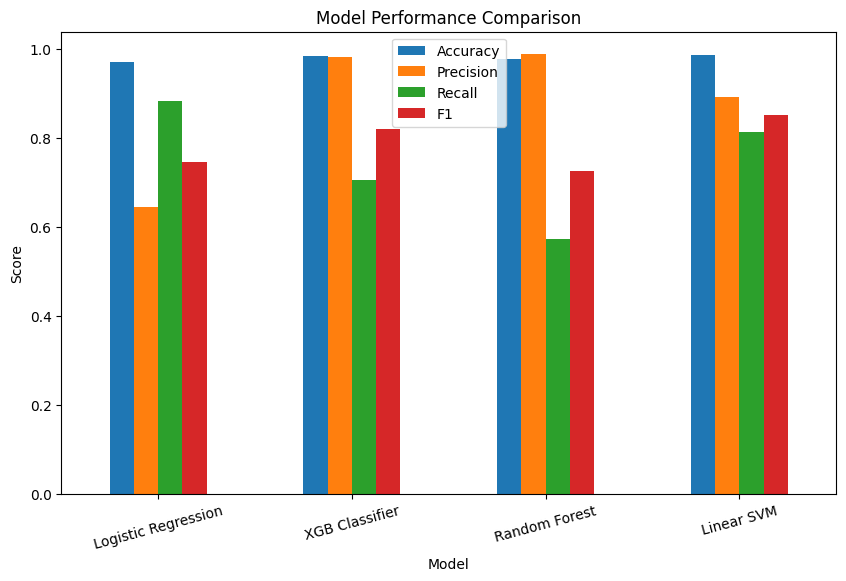

In [106]:
metrics_df = comparison.set_index('Model')

metrics_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.legend(loc='best')

plt.show()

# ROC-AUC Comparison

In [85]:
comparison['ROC_AUC'] = [
    0.9864,   # Logistic
    0.9920,   # XGB
    0.9909,   # RF
    0.9847    # SVM
]

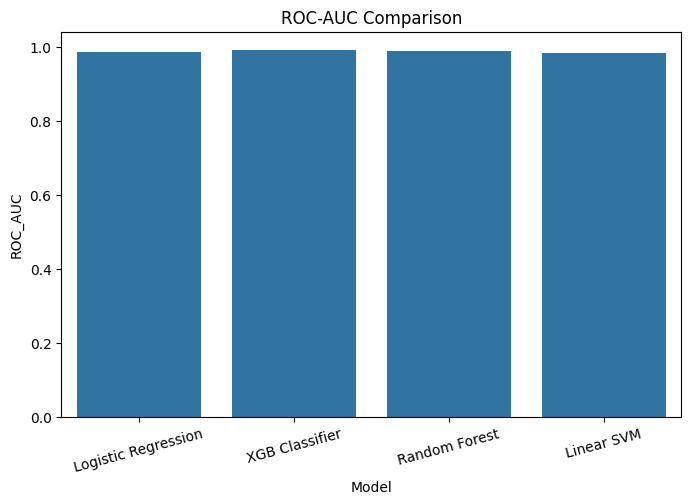

In [86]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='ROC_AUC'
)

plt.title("ROC-AUC Comparison")

plt.xticks(rotation=15)

plt.show()

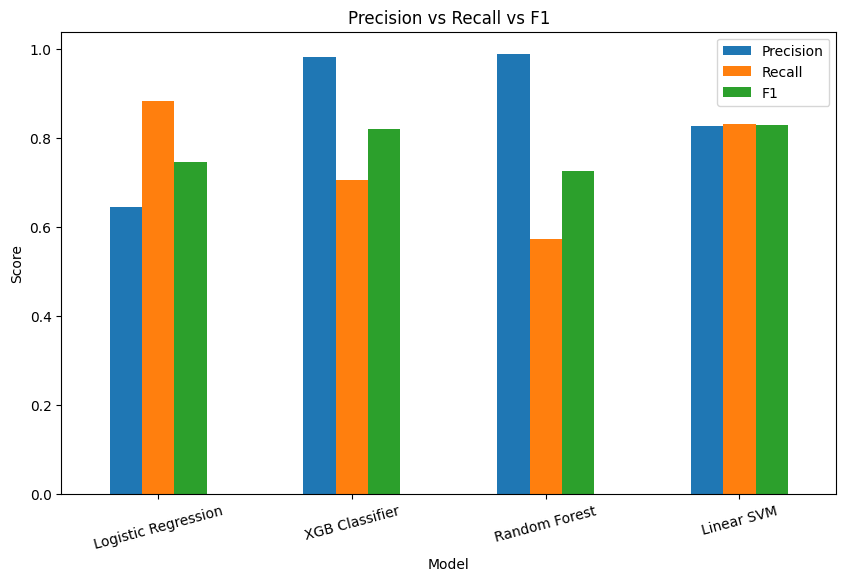

In [87]:

comparison.plot(
    x='Model',
    y=['Precision','Recall','F1'],
    kind='bar',
    figsize=(10,6)
)

plt.title("Precision vs Recall vs F1")
plt.ylabel("Score")

plt.xticks(rotation=15)

plt.show()

# Step 1: Save Final Model

In [110]:
import joblib

joblib.dump(svm_model, "fake_job_detector_Tuned.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Step 2: Check File

In [111]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'fake_job_detector.pkl', 'fake_job_detector_Tuned.pkl', 'fake_job_postings.csv', 'P1 Simple Only one datatype column.ipynb', 'Project1.Advance.ipynb', 'Project2-Copy1.ipynb', 'Untitled.ipynb', 'untitled.txt', 'Untitled2.ipynb']


# Step 3: Verify Model Load Ho Raha Hai

In [112]:
import joblib

model = joblib.load("fake_job_detector_Tuned.pkl")

print(type(model))

<class 'sklearn.pipeline.Pipeline'>


In [1]:
# pip install streamlit

# Comparision of Cross Validation

In [93]:
from sklearn.model_selection import cross_val_score
# Logistic Reg
lr_score = cross_val_score(LR, X, y, cv = 5, scoring = 'f1')

# Linear_svm 
svm_score = cross_val_score(svm_model, X, y, cv = 5, scoring = 'f1')

# XGBoost
xgb_score = cross_val_score(xgb_model, X, y, cv = 5, scoring = 'f1')

print("Logistic Reg:", lr_score.mean())
print("Linear_svm:", svm_score.mean())
print("XGBoot:", xgb_score.mean())

Logistic Reg: 0.6697231439308909
Linear_svm: 0.7758298729127879
XGBoot: 0.7789090349380322


# Hyperparameter Tuning 

In [95]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    "classifier__C": loguniform(0.001, 100),
    "classifier__loss": [
        "hinge",
        "squared_hinge"
    ],
    "classifier__max_iter": [
        3000,
        5000,
        10000,
        15000
    ]
}

random_search = RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END classifier__C=0.0745934328572655, classifier__loss=hinge, classifier__max_iter=10000; total time=   8.3s
[CV] END classifier__C=0.0745934328572655, classifier__loss=hinge, classifier__max_iter=10000; total time=   8.0s
[CV] END classifier__C=0.0745934328572655, classifier__loss=hinge, classifier__max_iter=10000; total time=   7.1s
[CV] END classifier__C=0.0745934328572655, classifier__loss=hinge, classifier__max_iter=10000; total time=   9.1s
[CV] END classifier__C=0.0745934328572655, classifier__loss=hinge, classifier__max_iter=10000; total time=   7.5s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=4.5705630998014515, classifier__loss=hinge, classifier__max_iter=3000; total time=  10.9s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=4.5705630998014515, classifier__loss=hinge, classifier__max_iter=3000; total time=  11.1s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=4.5705630998014515, classifier__loss=hinge, classifier__max_iter=3000; total time=  10.2s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=4.5705630998014515, classifier__loss=hinge, classifier__max_iter=3000; total time=  10.8s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=4.5705630998014515, classifier__loss=hinge, classifier__max_iter=3000; total time=  11.8s
[CV] END classifier__C=0.006026889128682512, classifier__loss=hinge, classifier__max_iter=10000; total time=   6.4s
[CV] END classifier__C=0.006026889128682512, classifier__loss=hinge, classifier__max_iter=10000; total time=   6.8s
[CV] END classifier__C=0.006026889128682512, classifier__loss=hinge, classifier__max_iter=10000; total time=   7.2s
[CV] END classifier__C=0.006026889128682512, classifier__loss=hinge, classifier__max_iter=10000; total time=   6.8s
[CV] END classifier__C=0.006026889128682512, classifier__loss=hinge, classifier__max_iter=10000; total time=   6.4s
[CV] END classifier__C=0.0019517224641449498, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.8s
[CV] END classifier__C=0.0019517224641449498, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.9s
[CV] END classifier__C=0.0019517224641449498, classifier__l

C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.008111941985431923, classifier__loss=hinge, classifier__max_iter=3000; total time=   6.2s
[CV] END classifier__C=0.008111941985431923, classifier__loss=hinge, classifier__max_iter=3000; total time=   7.4s
[CV] END classifier__C=0.008111941985431923, classifier__loss=hinge, classifier__max_iter=3000; total time=   6.2s
[CV] END classifier__C=0.033205591037519584, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   7.6s
[CV] END classifier__C=0.033205591037519584, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   7.4s
[CV] END classifier__C=0.033205591037519584, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   7.5s
[CV] END classifier__C=0.033205591037519584, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   7.8s
[CV] END classifier__C=0.033205591037519584, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   7.6s
[CV] END classifier__C=0.144452510227630

C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.19069966103000435, classifier__loss=hinge, classifier__max_iter=5000; total time=   8.2s
[CV] END classifier__C=0.19069966103000435, classifier__loss=hinge, classifier__max_iter=5000; total time=   8.9s
[CV] END classifier__C=0.19069966103000435, classifier__loss=hinge, classifier__max_iter=5000; total time=   7.3s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.19069966103000435, classifier__loss=hinge, classifier__max_iter=5000; total time=   8.4s
[CV] END classifier__C=0.009962513222055111, classifier__loss=hinge, classifier__max_iter=15000; total time=   6.5s
[CV] END classifier__C=0.009962513222055111, classifier__loss=hinge, classifier__max_iter=15000; total time=   6.5s
[CV] END classifier__C=0.009962513222055111, classifier__loss=hinge, classifier__max_iter=15000; total time=   6.4s
[CV] END classifier__C=0.009962513222055111, classifier__loss=hinge, classifier__max_iter=15000; total time=   6.9s
[CV] END classifier__C=0.009962513222055111, classifier__loss=hinge, classifier__max_iter=15000; total time=   6.3s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.9163741808778786, classifier__loss=hinge, classifier__max_iter=3000; total time=   8.9s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.9163741808778786, classifier__loss=hinge, classifier__max_iter=3000; total time=  10.1s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.9163741808778786, classifier__loss=hinge, classifier__max_iter=3000; total time=   9.8s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.9163741808778786, classifier__loss=hinge, classifier__max_iter=3000; total time=   8.9s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=0.9163741808778786, classifier__loss=hinge, classifier__max_iter=3000; total time=   8.8s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=1.0907475835157696, classifier__loss=hinge, classifier__max_iter=3000; total time=  10.9s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=1.0907475835157696, classifier__loss=hinge, classifier__max_iter=3000; total time=   8.9s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=1.0907475835157696, classifier__loss=hinge, classifier__max_iter=3000; total time=  10.1s
[CV] END classifier__C=1.0907475835157696, classifier__loss=hinge, classifier__max_iter=3000; total time=   8.9s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=1.0907475835157696, classifier__loss=hinge, classifier__max_iter=3000; total time=   8.7s
[CV] END classifier__C=0.0021147447960615704, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.7s
[CV] END classifier__C=0.0021147447960615704, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.9s
[CV] END classifier__C=0.0021147447960615704, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.6s
[CV] END classifier__C=0.0021147447960615704, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.9s
[CV] END classifier__C=0.0021147447960615704, classifier__loss=squared_hinge, classifier__max_iter=3000; total time=   6.6s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=67.32248920775338, classifier__loss=squared_hinge, classifier__max_iter=5000; total time=22.6min


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=67.32248920775338, classifier__loss=squared_hinge, classifier__max_iter=5000; total time=30.8min


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=67.32248920775338, classifier__loss=squared_hinge, classifier__max_iter=5000; total time=199.7min


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=67.32248920775338, classifier__loss=squared_hinge, classifier__max_iter=5000; total time=  33.1s


C:\Users\hp pc\anaconda3\envs\fresh_ml\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END classifier__C=67.32248920775338, classifier__loss=squared_hinge, classifier__max_iter=5000; total time=  31.8s
[CV] END classifier__C=0.03334792728637585, classifier__loss=hinge, classifier__max_iter=5000; total time=   4.3s
[CV] END classifier__C=0.03334792728637585, classifier__loss=hinge, classifier__max_iter=5000; total time=   4.1s
[CV] END classifier__C=0.03334792728637585, classifier__loss=hinge, classifier__max_iter=5000; total time=   4.3s
[CV] END classifier__C=0.03334792728637585, classifier__loss=hinge, classifier__max_iter=5000; total time=   4.3s
[CV] END classifier__C=0.03334792728637585, classifier__loss=hinge, classifier__max_iter=5000; total time=   4.2s
[CV] END classifier__C=2.6373339933815254, classifier__loss=hinge, classifier__max_iter=15000; total time=   7.3s
[CV] END classifier__C=2.6373339933815254, classifier__loss=hinge, classifier__max_iter=15000; total time=   7.6s
[CV] END classifier__C=2.6373339933815254, classifier__loss=hinge, classifier__max

# Best Model Extract

In [99]:
best_svm = random_search.best_estimator_
print(best_svm)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000),
                                                  'clean_text'),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['department', 'salary_range',
                                                   'employment_type',
                                                   'required_experience',
                                                   'required_education',
                                                   'industry', 'function']),
                                                 ('num', StandardScaler(),
                                                  ['telecommuting',
                                                   'has_company_logo',
                      

In [113]:
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score

pred = best_svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

Accuracy : 0.9860178970917226
Precision: 0.89171974522293
Recall   : 0.8092485549132948
F1 Score : 0.8484848484848485


# Step 2: ROC Curve

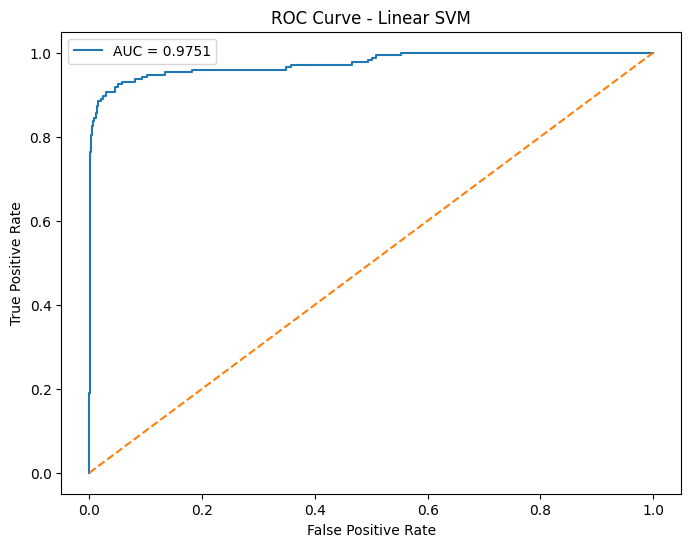

ROC-AUC: 0.9750696002677


In [116]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Scores
svm_scores = best_svm.decision_function(X_test)

# ROC Data
fpr, tpr, thresholds = roc_curve(y_test, svm_scores)

auc = roc_auc_score(y_test, svm_scores)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")
plt.legend()

plt.show()

print("ROC-AUC:", auc)

# Step 3: Confusion Matrix

[[3386   17]
 [  33  140]]


<Figure size 600x500 with 0 Axes>

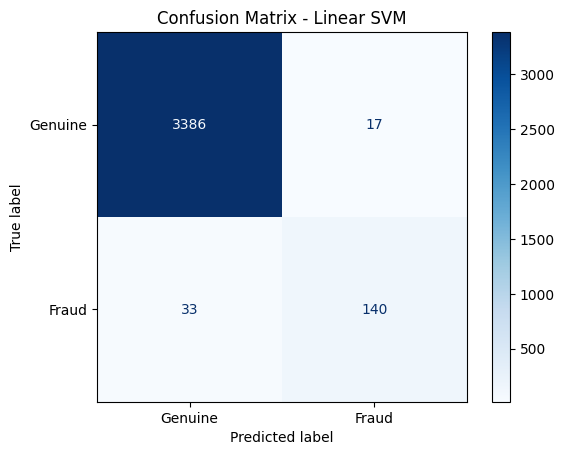

In [117]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = best_svm.predict(X_test)

cm = confusion_matrix(y_test, pred)

print(cm)

plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Genuine",
        "Fraud"
    ]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Linear SVM")

plt.show()

# Step 4 → Feature Importance 

In [118]:
import numpy as np
import pandas as pd

# Extract trained classifier
clf = best_svm.named_steps['classifier']

# Feature names
feature_names = best_svm.named_steps[
    'preprocessor'
].get_feature_names_out()

# Coefficients
coef = clf.coef_[0]

importance = pd.DataFrame({
    "Feature": feature_names,
    "Weight": coef
})

# Top Fraud Features
fraud_features = importance.sort_values(
    by="Weight",
    ascending=False
).head(20)

# Top Genuine Features
genuine_features = importance.sort_values(
    by="Weight",
    ascending=True
).head(20)

print("TOP FRAUD FEATURES")
display(fraud_features)

print("\nTOP GENUINE FEATURES")
display(genuine_features)

TOP FRAUD FEATURES


,Feature,Weight
574,text__bottom,2.509015
4520,text__therapy,2.411362
2644,text__link,2.329408
1684,text__executive,2.292542
303,text__aptitude,2.218475
6127,cat__department_biotech,2.218008
1012,text__continue,2.217068
5126,cat__department_Biotech,2.205238
2893,text__money,2.160235
793,text__church,2.103023



TOP GENUINE FEATURES


,Feature,Weight
6481,cat__salary_range_25-1000,-1.813296
2107,text__handling,-1.777444
4471,text__team,-1.759117
457,text__based,-1.732745
195,text__allied,-1.689550
3437,text__prepare,-1.664760
3090,text__opening,-1.651095
4295,text__starting,-1.552722
4602,text__trak,-1.550435
1966,text__fun,-1.545042


In [119]:
scores = best_svm.decision_function(X_test)

print(scores[:10])

[-1.48007222 -2.01728161 -2.10737512 -2.35296562 -2.65010867 -2.05170787
 -2.42931684 -1.1589818  -2.38453481 -1.6152525 ]


# For industry Level Use this model

In [120]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_svm = CalibratedClassifierCV(
    best_svm,
    method='sigmoid',
    cv=5
)

calibrated_svm.fit(X_train, y_train)

probs = calibrated_svm.predict_proba(X_test)

print(probs[:5])

[[9.86568989e-01 1.34310108e-02]
 [9.97801744e-01 2.19825619e-03]
 [9.97853624e-01 2.14637628e-03]
 [9.98948536e-01 1.05146434e-03]
 [9.99388981e-01 6.11019225e-04]]


In [122]:
from sklearn.metrics import classification_report

pred = calibrated_svm.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.96      0.75      0.84       173

    accuracy                           0.99      3576
   macro avg       0.98      0.87      0.92      3576
weighted avg       0.99      0.99      0.99      3576



In [123]:
import joblib

joblib.dump(calibrated_svm, "fake_job_detector_pro.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [124]:
import os

print(os.listdir())


['.ipynb_checkpoints', 'app.py', 'fake_job_detector.pkl', 'fake_job_detector_pro.pkl', 'fake_job_detector_Tuned.pkl', 'fake_job_postings.csv', 'P1 Simple Only one datatype column.ipynb', 'Project1.Advance.ipynb', 'Project2-Copy1.ipynb', 'Untitled.ipynb', 'untitled.txt', 'Untitled2.ipynb']


In [126]:
import joblib

model = joblib.load("fake_job_detector_pro.pkl")

print(type(model))

<class 'sklearn.calibration.CalibratedClassifierCV'>
